# Deep Sets for MTG Deck Classification (Binary)

This notebook is an easier version of deepset.ipynb. It trains a Deep Sets classifier to solve the binary class classification problem of being able to predict **Casual (0)** vs **Competitive (1)** decks, as opposed to the multi-class classification that this architecture is struggling with.

Note: This notebook confirms that the first batch of data with labelled decks from MTGTop8 and Moxfield are not well labelled, in that Moxfield labels are basically noise, but cEDH decks are well labelled in this set.

## 1) Setup

In [38]:
import json
import logging
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from gensim.models import Word2Vec
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

BATCH_SIZE = 64
EPOCHS = 15
EMBEDDING_SIZE = 512
MAX_DECK_LEN = 115

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = Path("../../data")
INPUT_FILE = DATA_DIR / "megacorpus_clean.jsonl"
INPUT_EDH = DATA_DIR / "clean-edh-decks.jsonl"
MODEL_OUTPUT = DATA_DIR / "general-item2vec_mtg.model"

TRAIN_EMBEDDINGS = False #toggle for fresh embeddings

logging.basicConfig(format="%(asctime)s : %(levelname)s : %(message)s", level=logging.INFO)
print(f"Using device: {DEVICE}")

Using device: cuda


## 2) Card Normalization and Filtering

In [39]:
RAW_BASIC_LANDS = {
    "Plains",
    "Island",
    "Swamp",
    "Mountain",
    "Forest",
    "Wastes",
    "Snow-Covered Plains",
    "Snow-Covered Island",
    "Snow-Covered Swamp",
    "Snow-Covered Mountain",
    "Snow-Covered Forest",
}

def normalize_card_name(name: str) -> str:
    name = name.lower()
    front_face = re.split(r"\s*//?\s*", name)[0]
    return front_face.strip()

BASIC_LANDS = {normalize_card_name(card) for card in RAW_BASIC_LANDS}

def filter_basic_lands(cards):
    return [c for c in cards if normalize_card_name(c) not in BASIC_LANDS]

## 3) Embedding Corpus and Word2Vec Utilities

In [40]:
class MTGDeckCorpus:
    def __init__(self, filepath, max_per_format=None):
        self.filepath = filepath
        self.max_per_format = max_per_format or {"MO": 40000, "LE": 40000}

    def __iter__(self):
        format_counts = {}
        with open(self.filepath, "r", encoding="utf-8") as infile:
            for line in infile:
                if not line.strip():
                    continue

                data = json.loads(line)
                fmt = data.get("source", "CEDH")

                format_counts[fmt] = format_counts.get(fmt, 0) + 1
                if fmt in self.max_per_format and format_counts[fmt] > self.max_per_format[fmt]:
                    continue

                if "cards" in data:
                    all_cards = data["cards"]
                else:
                    mainboard_cards = list(data.get("mainboard", {}).keys())
                    sideboard_cards = list(data.get("sideboard", {}).keys())
                    all_cards = mainboard_cards + sideboard_cards

                clean_deck = filter_basic_lands(all_cards)
                if len(clean_deck) >= 10:
                    yield clean_deck


def train_embeddings():
    print(f"Initializing stream from {INPUT_FILE}...")
    sentences = MTGDeckCorpus(INPUT_FILE)
    MODEL_OUTPUT.parent.mkdir(parents=True, exist_ok=True)

    print("Training Gensim Word2Vec model...")
    model = Word2Vec(
        sentences=sentences,
        vector_size=EMBEDDING_SIZE,
        window=115,
        min_count=3,
        sg=1,
        workers=12,
        epochs=10,
    )

    print(f"Saving model to {MODEL_OUTPUT}")
    model.save(str(MODEL_OUTPUT))


def load_gensim_embeddings(gensim_model_path):
    print(f"Loading Gensim model from {gensim_model_path}...")
    g_model = Word2Vec.load(str(gensim_model_path))

    gensim_words = g_model.wv.index_to_key
    vector_size = g_model.vector_size
    vocab_size = len(gensim_words) + 2

    embedding_matrix = np.zeros((vocab_size, vector_size))
    vocab = {"<PAD>": 0, "<UNK>": 1}

    for i, word in enumerate(gensim_words):
        pytorch_id = i + 2
        vocab[word] = pytorch_id
        embedding_matrix[pytorch_id] = g_model.wv[word]

    embedding_tensor = torch.FloatTensor(embedding_matrix)
    print(f"Loaded {vocab_size} vectors with dimension {vector_size}.")
    return vocab, embedding_tensor

In [41]:
if TRAIN_EMBEDDINGS:
    train_embeddings()

vocab_dict, pretrained_weights = load_gensim_embeddings(MODEL_OUTPUT)

2026-03-15 00:21:03,233 : INFO : loading Word2Vec object from ..\..\data\general-item2vec_mtg.model
2026-03-15 00:21:03,243 : INFO : loading wv recursively from ..\..\data\general-item2vec_mtg.model.wv.* with mmap=None
2026-03-15 00:21:03,244 : INFO : loading vectors from ..\..\data\general-item2vec_mtg.model.wv.vectors.npy with mmap=None
2026-03-15 00:21:03,266 : INFO : loading syn1neg from ..\..\data\general-item2vec_mtg.model.syn1neg.npy with mmap=None
2026-03-15 00:21:03,285 : INFO : setting ignored attribute cum_table to None
2026-03-15 00:21:03,399 : INFO : Word2Vec lifecycle event {'fname': '..\\..\\data\\general-item2vec_mtg.model', 'datetime': '2026-03-15T00:21:03.399366', 'gensim': '4.4.0', 'python': '3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'loaded'}


Loading Gensim model from ..\..\data\general-item2vec_mtg.model...
Loaded 22439 vectors with dimension 512.


## 4) Binary Dataset (Casual vs Competitive)

In [ ]:
class MTGBinaryDataset(Dataset):
    def __init__(self, jsonl_filepath, vocab, max_len=MAX_DECK_LEN):
        self.max_len = max_len
        self.vocab = vocab
        self.inputs = []
        self.labels = []

        print(f"Parsing decks from {jsonl_filepath}...")
        with open(jsonl_filepath, "r", encoding="utf-8") as infile:
            for line in infile:
                if not line.strip():
                    continue

                data = json.loads(line)
                source_str = data.get("source", "").lower()

                if "cedh" in source_str: #see if we can tell the difference between moxfield decks and decks that won tournaments
                    label = 1
                elif any(f"bracket-{i}" in source_str or f"bracket{i}" in source_str for i in range(1, 5)):
                    label = 0
                else:
                    continue

                main = list(data.get("mainboard", {}).keys())
                side = list(data.get("sideboard", {}).keys())
                deck_cards = filter_basic_lands(main + side)

                if len(deck_cards) < 10:
                    continue

                deck_ids = [self.vocab.get(card, 1) for card in deck_cards]
                if len(deck_ids) > self.max_len:
                    deck_ids = deck_ids[: self.max_len]
                else:
                    deck_ids += [0] * (self.max_len - len(deck_ids))

                self.inputs.append(deck_ids)
                self.labels.append(label)

        self.inputs = torch.tensor(self.inputs, dtype=torch.long)
        self.labels = torch.tensor(self.labels, dtype=torch.long)

        class_counts = torch.bincount(self.labels, minlength=2)
        self.class_weights = 1.0 / class_counts.clamp(min=1).float()
        self.class_weights = self.class_weights / self.class_weights.sum()

        print(f"Dataset ready: {len(self.inputs)} labeled decks")
        print(f"Class distribution -> Casual: {class_counts[0]}, Competitive: {class_counts[1]}")

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]

## 5) Deep Sets Model

In [43]:
class EDHAttentionDeepSets(nn.Module):
    def __init__(self, vocab_size, embedding_dim=EMBEDDING_SIZE, hidden_dim=128, pretrained_weights=None):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if pretrained_weights is not None:
            self.embedding.weight.data.copy_(pretrained_weights)
            self.embedding.weight.requires_grad = True

        self.card_mlp = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.attention_net = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

        self.deck_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x):
        mask = (x != 0).float().unsqueeze(-1)
        embedded = self.embedding(x)
        card_features = self.card_mlp(embedded)

        attn_scores = self.attention_net(card_features)
        attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_weights = F.softmax(attn_scores, dim=1)

        deck_vector = torch.sum(attn_weights * card_features, dim=1)
        return self.deck_mlp(deck_vector)

## 6) Data Split and Loaders

In [44]:
full_dataset = MTGBinaryDataset(INPUT_EDH, vocab_dict)

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

split_generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=split_generator,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train/Val/Test sizes: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")

Parsing decks from ..\..\data\clean-edh-decks.jsonl...
Dataset ready: 50447 labeled decks
Class distribution -> Casual: 35734, Competitive: 14713
Train/Val/Test sizes: 40357/5044/5046


## 7) Training Utilities

In [45]:
def evaluate(net, loader, criterion):
    net.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return correct / total, total_loss / len(loader)


def train_net(net, train_loader, val_loader, class_weights, learning_rate=3e-4, num_epochs=15):
    net.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

    optimizer = optim.AdamW(
        [
            {"params": net.embedding.parameters(), "lr": 1e-5},
            {
                "params": [p for n, p in net.named_parameters() if "embedding" not in n],
                "lr": learning_rate,
            },
        ],
        weight_decay=1e-4,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    # Baseline before any optimization step.
    train_acc, train_loss = evaluate(net, train_loader, criterion)
    val_acc, val_loss = evaluate(net, val_loader, criterion)

    history["epoch"].append(0)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(100 * train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(100 * val_acc)

    print(
        f"Epoch 0/{num_epochs} | "
        f"Train Acc: {history['train_acc'][-1]:.2f}% | "
        f"Val Acc: {history['val_acc'][-1]:.2f}%"
    )

    for epoch in range(1, num_epochs + 1):
        net.train()
        total_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        val_acc, val_loss = evaluate(net, val_loader, criterion)
        scheduler.step(val_loss)

        history["epoch"].append(epoch)
        history["train_loss"].append(total_loss / len(train_loader))
        history["train_acc"].append(100 * correct / total)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(100 * val_acc)

        print(
            f"Epoch {epoch}/{num_epochs} | "
            f"Train Acc: {history['train_acc'][-1]:.2f}% | "
            f"Val Acc: {history['val_acc'][-1]:.2f}%"
        )

    return history


def plot_training_curve(history):
    epochs = history.get("epoch", list(range(1, len(history["train_loss"]) + 1)))

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.title("Loss")
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.title("Accuracy")
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Validation")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()

## 8) Train Model

Epoch 0/15 | Train Acc: 22.97% | Val Acc: 22.16%
Epoch 1/15 | Train Acc: 93.01% | Val Acc: 94.15%
Epoch 2/15 | Train Acc: 93.96% | Val Acc: 93.81%
Epoch 3/15 | Train Acc: 94.31% | Val Acc: 94.33%
Epoch 4/15 | Train Acc: 94.67% | Val Acc: 94.31%
Epoch 5/15 | Train Acc: 94.96% | Val Acc: 95.02%
Epoch 6/15 | Train Acc: 95.13% | Val Acc: 94.45%
Epoch 7/15 | Train Acc: 95.66% | Val Acc: 93.75%
Epoch 8/15 | Train Acc: 95.83% | Val Acc: 94.21%
Epoch 9/15 | Train Acc: 96.47% | Val Acc: 94.37%
Epoch 10/15 | Train Acc: 96.70% | Val Acc: 94.59%
Epoch 11/15 | Train Acc: 96.95% | Val Acc: 95.40%
Epoch 12/15 | Train Acc: 97.03% | Val Acc: 95.28%
Epoch 13/15 | Train Acc: 97.35% | Val Acc: 95.66%
Epoch 14/15 | Train Acc: 97.50% | Val Acc: 95.90%
Epoch 15/15 | Train Acc: 97.61% | Val Acc: 95.28%


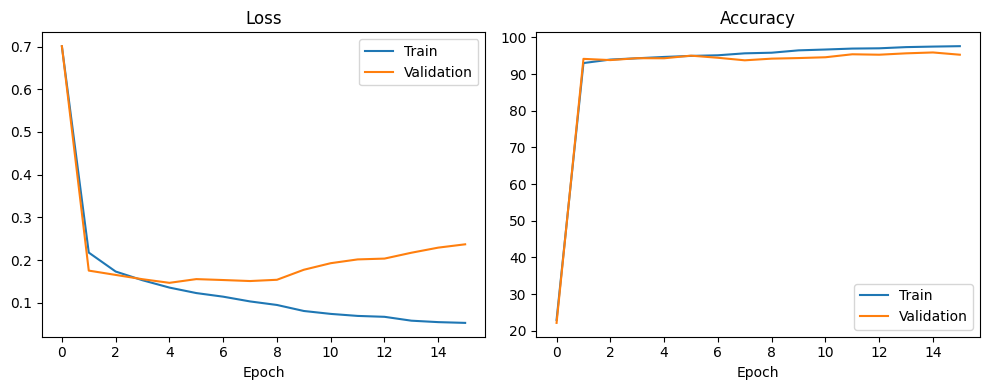

In [46]:
model = EDHAttentionDeepSets(
    vocab_size=len(vocab_dict),
    embedding_dim=EMBEDDING_SIZE,
    hidden_dim=128,
    pretrained_weights=pretrained_weights,
).to(DEVICE)

history = train_net(
    model,
    train_loader,
    val_loader,
    full_dataset.class_weights,
    learning_rate=1e-3,
    num_epochs=EPOCHS,
)

plot_training_curve(history)

## 9) Evaluation and Interpretability

In [47]:
def visualize_deck_attention(net, deck_ids, vocab, top_n=10, real_label=None):
    net.eval()
    inv_vocab = {v: k for k, v in vocab.items()}
    class_map = {0: "Casual", 1: "Competitive"}

    with torch.no_grad():
        if not isinstance(deck_ids, torch.Tensor):
            deck_ids = torch.tensor(deck_ids)

        x = deck_ids.unsqueeze(0).to(DEVICE)
        mask = (x != 0).float().unsqueeze(-1)

        embedded = net.embedding(x)
        card_features = net.card_mlp(embedded)

        attn_scores = net.attention_net(card_features)
        attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_weights = F.softmax(attn_scores, dim=1)

        deck_vector = torch.sum(attn_weights * card_features, dim=1)
        logits = net.deck_mlp(deck_vector)
        pred_idx = torch.argmax(logits, dim=1).item()

    weights_np = attn_weights.squeeze().cpu().numpy()
    ids_np = deck_ids.cpu().numpy()

    valid_indices = (ids_np != 0) & (ids_np != 1)
    clean_ids = ids_np[valid_indices]
    clean_weights = weights_np[valid_indices]

    card_names = [inv_vocab.get(i, f"ID:{i}") for i in clean_ids]

    sorted_indices = np.argsort(clean_weights)[::-1][:top_n]
    top_cards = [card_names[i] for i in sorted_indices]
    top_weights = [clean_weights[i] for i in sorted_indices]

    plt.figure(figsize=(10, 6))
    plt.barh(top_cards, top_weights, color="teal")
    plt.xlabel("Attention Weight (Importance)")

    title = f"Predicted: {class_map[pred_idx]}"
    if real_label is not None:
        title += f" (Actual: {class_map[int(real_label)]})"

    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(net, test_loader):
    net.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            outputs = net(inputs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Casual", "Competitive"],
        yticklabels=["Casual", "Competitive"],
    )
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title("Binary Confusion Matrix on Test Set")
    plt.tight_layout()
    plt.show()

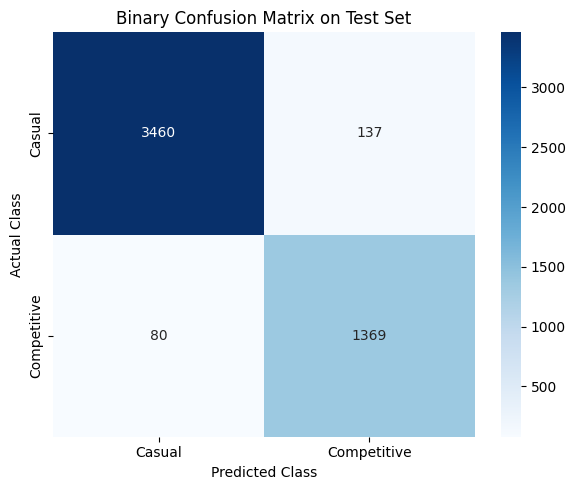

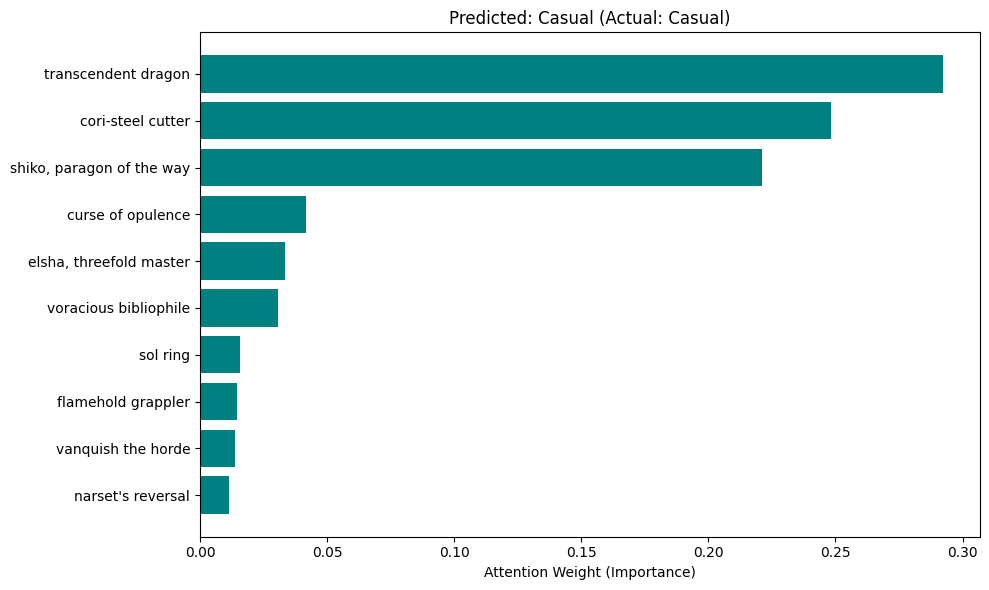

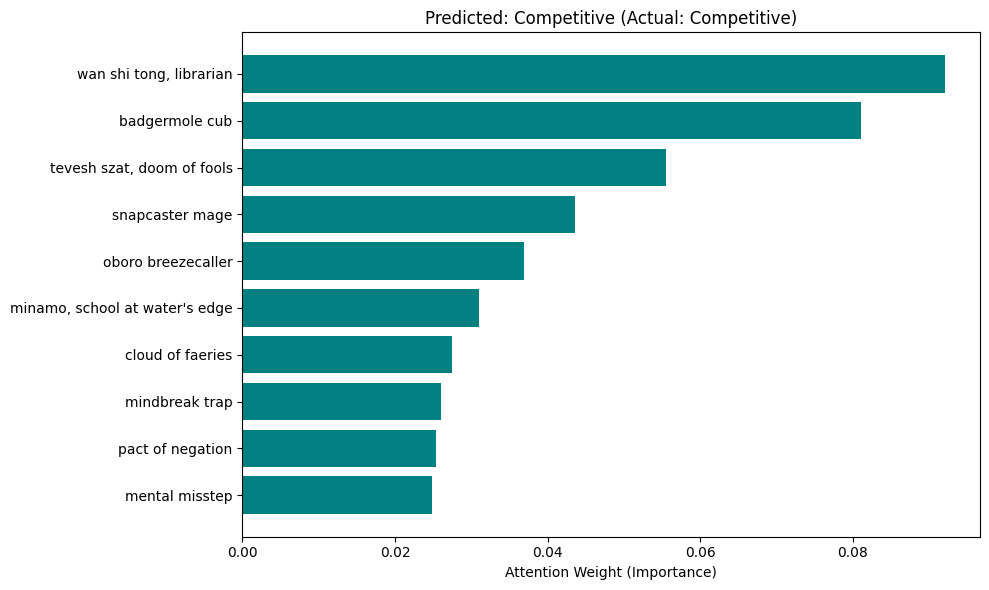

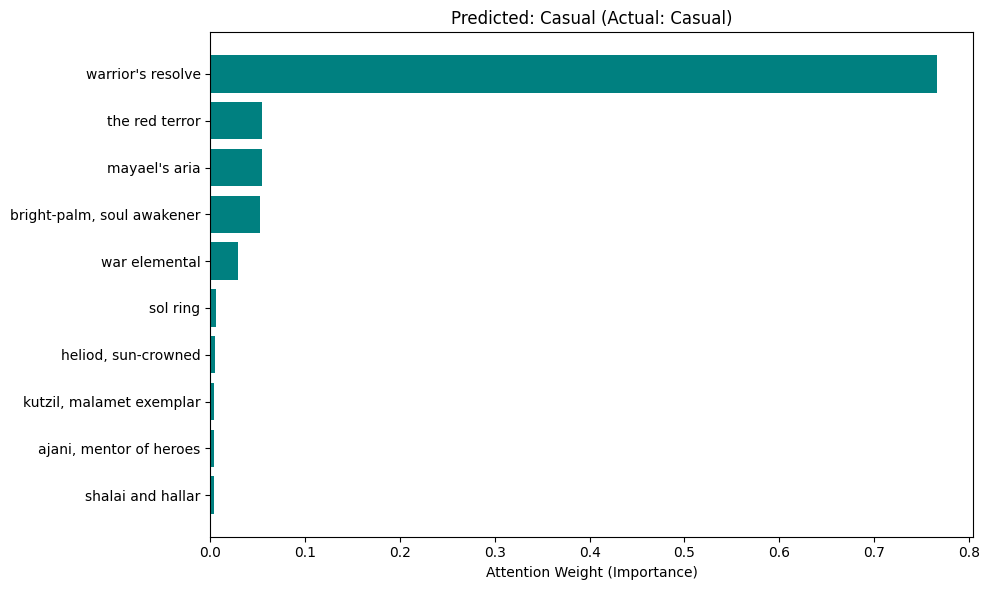

In [49]:
plot_confusion_matrix(model, test_loader)

sample_inputs, sample_label = test_ds[0]
visualize_deck_attention(model, sample_inputs, vocab_dict, top_n=10, real_label=sample_label)

sample_inputs, sample_label = test_ds[1]
visualize_deck_attention(model, sample_inputs, vocab_dict, top_n=10, real_label=sample_label)

sample_inputs, sample_label = test_ds[2]
visualize_deck_attention(model, sample_inputs, vocab_dict, top_n=10, real_label=sample_label)